# Telco Churn - Phase 3-4: Imbalance Handling, Modeling, and Evaluation

In [1]:
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from imblearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

sys.path.append(str(Path("..").resolve()))

from src.models import (
    clone_for_resampling,
    cross_validate_model,
    evaluate_on_test,
    find_optimal_threshold,
    get_hyperparam_grid,
    get_model_configs,
    get_resampling_strategies,
    load_processed_data,
)

## 1) Load Processed Data

In [2]:
x_train, x_test, y_train, y_test = load_processed_data("../data/processed")

print("x_train:", x_train.shape)
print("x_test:", x_test.shape)
print("y_train balance:")
print(y_train.value_counts(normalize=True))
print("y_test balance:")
print(y_test.value_counts(normalize=True))

x_train: (5634, 40)
x_test: (1409, 40)
y_train balance:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64
y_test balance:
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


## 2) Imbalance Strategy Comparison (CV)

Compares baseline, class-weight balancing, SMOTE, and SMOTE+Tomek.

In [3]:
base_models = {
    "logistic_regression": get_model_configs()["logistic_regression"],
    "random_forest": get_model_configs()["random_forest"],
    "lightgbm": get_model_configs()["lightgbm"],
}
balanced_models = {
    "logistic_regression_balanced": get_model_configs()["logistic_regression_balanced"],
    "random_forest_balanced": get_model_configs()["random_forest_balanced"],
    "lightgbm_balanced": get_model_configs()["lightgbm_balanced"],
}
resampling = get_resampling_strategies()

results = []

# Baseline + SMOTE strategies for base models.
for model_name, model in base_models.items():
    for strategy_name, sampler in resampling.items():
        model_for_run = clone_for_resampling(model, strategy_name)
        estimator = (
            Pipeline([("sampler", sampler), ("model", model_for_run)])
            if sampler is not None
            else model_for_run
        )
        summary = cross_validate_model(estimator, x_train, y_train, cv=5)
        summary.update({"model": model_name, "strategy": strategy_name})
        results.append(summary)

# Class-weight strategy from balanced variants.
for model_name, model in balanced_models.items():
    summary = cross_validate_model(model, x_train, y_train, cv=5)
    summary.update({"model": model_name.replace("_balanced", ""), "strategy": "class_weight_balanced"})
    results.append(summary)

cv_results_df = pd.DataFrame(results).sort_values(by=["f1_mean", "roc_auc_mean"], ascending=False)
cv_results_df.reset_index(drop=True, inplace=True)
cv_results_df.head(12)

,f1_mean,f1_std,roc_auc_mean,roc_auc_std,precision_mean,precision_std,recall_mean,recall_std,model,strategy
0,0.628469,0.018117,0.846941,0.011290,0.520759,0.015764,0.792642,0.026164,logistic_regression,class_weight_balanced
1,0.622262,0.022386,0.839479,0.011719,0.519834,0.019316,0.775251,0.030755,logistic_regression,smote
2,0.622152,0.021807,0.839547,0.011436,0.518180,0.019372,0.778595,0.028724,logistic_regression,smote_tomek
3,0.599989,0.022181,0.825398,0.006181,0.559057,0.018055,0.647492,0.028268,lightgbm,class_weight_balanced
4,0.594980,0.028132,0.847091,0.011533,0.674278,0.024649,0.533110,0.035621,logistic_regression,baseline
5,0.591863,0.013183,0.823941,0.011339,0.576040,0.013695,0.608696,0.015106,random_forest,smote_tomek
6,0.589606,0.022889,0.824987,0.009367,0.581086,0.019758,0.598662,0.028925,random_forest,smote
7,0.571055,0.018801,0.820973,0.007851,0.587260,0.018008,0.555853,0.021300,lightgbm,smote
8,0.565268,0.014276,0.819949,0.008430,0.575074,0.013571,0.555853,0.016026,lightgbm,smote_tomek
9,0.553480,0.017762,0.820595,0.008344,0.604869,0.021449,0.510368,0.018513,lightgbm,baseline


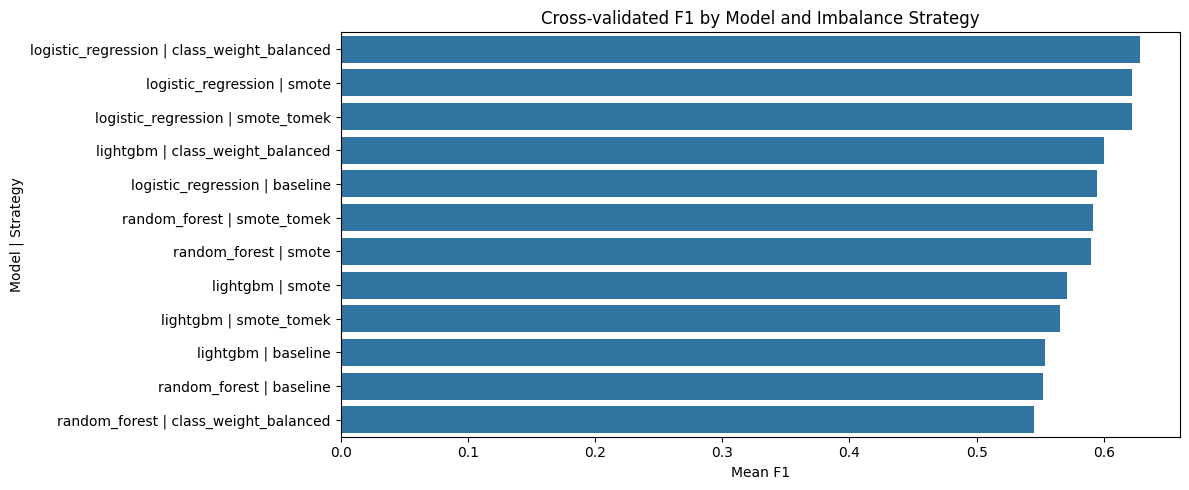

In [4]:
plt.figure(figsize=(12, 5))
plot_df = cv_results_df.copy()
plot_df["label"] = plot_df["model"] + " | " + plot_df["strategy"]
sns.barplot(data=plot_df, x="f1_mean", y="label", orient="h")
plt.title("Cross-validated F1 by Model and Imbalance Strategy")
plt.xlabel("Mean F1")
plt.ylabel("Model | Strategy")
plt.tight_layout()
plt.show()

## 3) Select Best Strategy

In [5]:
best_row = cv_results_df.iloc[0]
best_model_name = best_row["model"]
best_strategy = best_row["strategy"]

print("Selected model:", best_model_name)
print("Selected strategy:", best_strategy)
print("CV F1 mean:", round(best_row["f1_mean"], 4))
print("CV ROC-AUC mean:", round(best_row["roc_auc_mean"], 4))

Selected model: logistic_regression
Selected strategy: class_weight_balanced
CV F1 mean: 0.6285
CV ROC-AUC mean: 0.8469


## 4) Hyperparameter Tuning (RandomizedSearchCV)

In [6]:
all_models = get_model_configs()
selected_key = best_model_name if best_strategy != "class_weight_balanced" else f"{best_model_name}_balanced"
selected_model = clone(all_models[selected_key])

if best_strategy in {"smote", "smote_tomek"}:
    selected_model = clone_for_resampling(selected_model, best_strategy)
    sampler = get_resampling_strategies()[best_strategy]
    tune_estimator = Pipeline([("sampler", sampler), ("model", selected_model)])
    param_distributions = {f"model__{k}": v for k, v in get_hyperparam_grid(best_model_name).items()}
else:
    tune_estimator = selected_model
    param_distributions = get_hyperparam_grid(best_model_name)

random_search = RandomizedSearchCV(
    estimator=tune_estimator,
    param_distributions=param_distributions,
    n_iter=50,
    scoring="f1",
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    n_jobs=-1,
    random_state=42,
    verbose=0,
)
random_search.fit(x_train, y_train)

best_estimator = random_search.best_estimator_
print("Best CV F1 from random search:", round(random_search.best_score_, 4))
print("Best params:")
print(random_search.best_params_)

/Users/backup/Desktop/Telco customer Churn/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(
/Users/backup/Desktop/Telco customer Churn/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(
/Users/backup/Desktop/Telco customer Churn/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(
/Users/backup/Desktop/Telco customer Churn/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(
/Users/backup/Desktop/Telco customer

/Users/backup/Desktop/Telco customer Churn/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(
/Users/backup/Desktop/Telco customer Churn/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(


/Users/backup/Desktop/Telco customer Churn/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(
/Users/backup/Desktop/Telco customer Churn/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(
/Users/backup/Desktop/Telco customer Churn/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(
/Users/backup/Desktop/Telco customer Churn/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(
/Users/backup/Desktop/Telco customer

/Users/backup/Desktop/Telco customer Churn/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(
/Users/backup/Desktop/Telco customer Churn/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(
/Users/backup/Desktop/Telco customer Churn/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(


/Users/backup/Desktop/Telco customer Churn/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(
/Users/backup/Desktop/Telco customer Churn/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(
/Users/backup/Desktop/Telco customer Churn/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(
/Users/backup/Desktop/Telco customer Churn/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(


...

/Users/backup/Desktop/Telco customer Churn/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(
/Users/backup/Desktop/Telco customer Churn/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(
/Users/backup/Desktop/Telco customer Churn/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(


/Users/backup/Desktop/Telco customer Churn/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(
/Users/backup/Desktop/Telco customer Churn/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(


/Users/backup/Desktop/Telco customer Churn/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(
/Users/backup/Desktop/Telco customer Churn/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(
/Users/backup/Desktop/Telco customer Churn/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(
/Users/backup/Desktop/Telco customer Churn/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(


/Users/backup/Desktop/Telco customer Churn/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(
/Users/backup/Desktop/Telco customer Churn/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(
/Users/backup/Desktop/Telco customer Churn/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(


Best CV F1 from random search: 0.6327
Best params:
{'solver': 'lbfgs', 'C': 0.010826367338740546}


## 5) Final Test Evaluation

Test ROC-AUC: 0.8423
Test PR-AUC: 0.6454
Test F1: 0.623
Test Precision: 0.5148
Test Recall: 0.7888

Classification report (default 0.5 threshold):
              precision    recall  f1-score   support

           0     0.9055    0.7314    0.8092      1035
           1     0.5148    0.7888    0.6230       374

    accuracy                         0.7466      1409
   macro avg     0.7102    0.7601    0.7161      1409
weighted avg     0.8018    0.7466    0.7598      1409



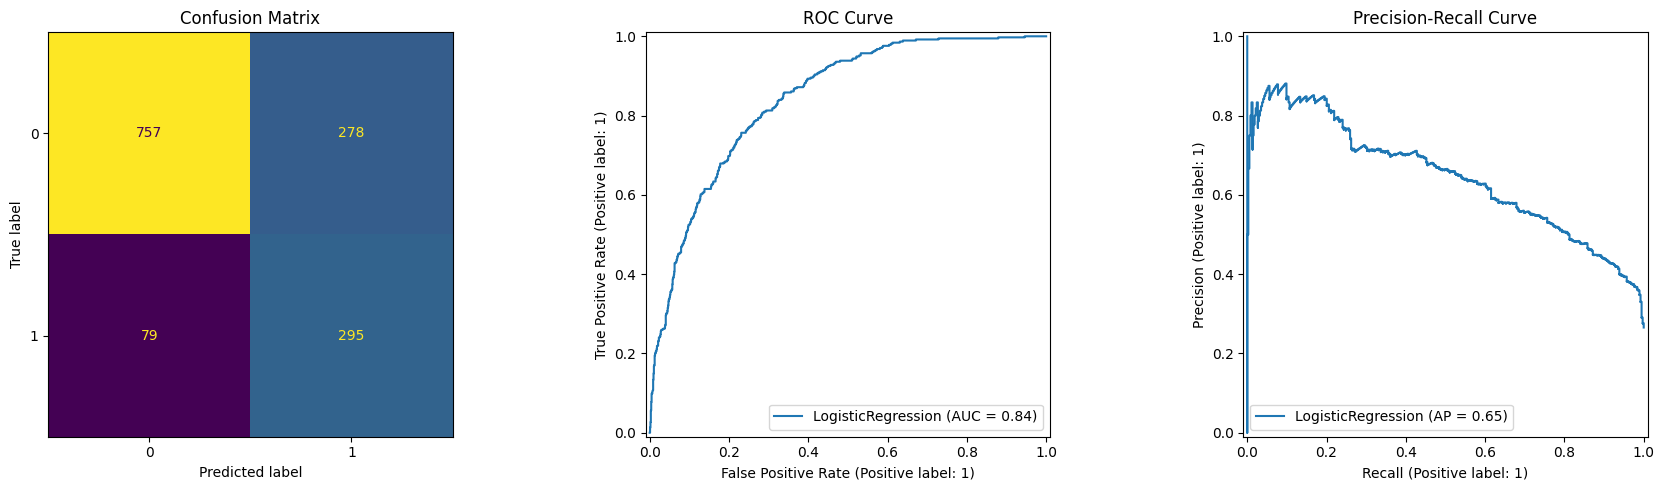

In [7]:
test_metrics = evaluate_on_test(best_estimator, x_test, y_test)

print("Test ROC-AUC:", round(test_metrics["roc_auc"], 4))
print("Test PR-AUC:", round(test_metrics["pr_auc"], 4))
print("Test F1:", round(test_metrics["f1"], 4))
print("Test Precision:", round(test_metrics["precision"], 4))
print("Test Recall:", round(test_metrics["recall"], 4))

print("\nClassification report (default 0.5 threshold):")
print(classification_report(y_test, test_metrics["y_pred"], digits=4))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ConfusionMatrixDisplay(test_metrics["confusion_matrix"]).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix")
RocCurveDisplay.from_estimator(best_estimator, x_test, y_test, ax=axes[1])
axes[1].set_title("ROC Curve")
PrecisionRecallDisplay.from_estimator(best_estimator, x_test, y_test, ax=axes[2])
axes[2].set_title("Precision-Recall Curve")
plt.tight_layout()
plt.show()

## 6) Threshold Tuning

In [8]:
optimal_threshold = find_optimal_threshold(best_estimator, x_test, y_test)
y_proba = best_estimator.predict_proba(x_test)[:, 1]
y_pred_opt = (y_proba >= optimal_threshold).astype(int)

print("Optimal threshold:", round(optimal_threshold, 4))
print("Metrics at optimal threshold:")
print("F1:", round(f1_score(y_test, y_pred_opt), 4))
print("Precision:", round(precision_score(y_test, y_pred_opt, zero_division=0), 4))
print("Recall:", round(recall_score(y_test, y_pred_opt, zero_division=0), 4))
print("\nClassification report (optimal threshold):")
print(classification_report(y_test, y_pred_opt, digits=4))

Optimal threshold: 0.5406
Metrics at optimal threshold:
F1: 0.6317
Precision: 0.5421
Recall: 0.7567

Classification report (optimal threshold):
              precision    recall  f1-score   support

           0     0.8974    0.7691    0.8283      1035
           1     0.5421    0.7567    0.6317       374

    accuracy                         0.7658      1409
   macro avg     0.7198    0.7629    0.7300      1409
weighted avg     0.8031    0.7658    0.7761      1409



## 7) Save Best Model and Metadata

In [9]:
models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(best_estimator, models_dir / "best_model.joblib")
joblib.dump(float(optimal_threshold), models_dir / "best_threshold.joblib")

summary = {
    "best_model": best_model_name,
    "best_strategy": best_strategy,
    "cv_f1_mean": float(best_row["f1_mean"]),
    "test_f1_default": float(test_metrics["f1"]),
    "test_roc_auc": float(test_metrics["roc_auc"]),
    "test_pr_auc": float(test_metrics["pr_auc"]),
    "optimal_threshold": float(optimal_threshold),
}
pd.Series(summary).to_json(models_dir / "model_summary.json", indent=2)

cv_results_df.to_csv(models_dir / "model_cv_results.csv", index=False)

print("Saved:")
print("-", models_dir / "best_model.joblib")
print("-", models_dir / "best_threshold.joblib")
print("-", models_dir / "model_summary.json")
print("-", models_dir / "model_cv_results.csv")

Saved:
- ../models/best_model.joblib
- ../models/best_threshold.joblib
- ../models/model_summary.json
- ../models/model_cv_results.csv
